# Validación de predicciones

Validamos los resultados de las proyecciones realizadas con el modelo

## Carga de librerías

In [40]:
import os

from dotenv import find_dotenv, load_dotenv
from sqlalchemy import create_engine
from sqlalchemy.engine import URL
import pandas as pd
import polars as pl

load_dotenv(find_dotenv(usecwd=True))

True

## Conexión a la base de datos operativa

In [41]:
postgres_host = os.getenv("POSTGRES_HOST")
postgres_port = os.getenv("POSTGRES_PORT", "5432")
postgres_database = os.getenv("POSTGRES_DB")
postgres_user = os.getenv("POSTGRES_USER")
postgres_password = os.getenv("POSTGRES_PASSWORD")

engine = create_engine(
    URL.create(
        "postgresql+psycopg2",
        username=postgres_user,
        password=postgres_password,
        host=postgres_host,
        port=int(postgres_port),
        database=postgres_database,
    )
)

## Descarga de datos

In [42]:
with engine.connect() as connection:
    df = pl.read_database("SELECT * FROM zc_cliente_consolidado_predicciones", connection)

df = df.filter(pl.col("valor_real").is_not_null())

In [53]:
fecha_inicio = df.select(pl.col("fecha_prediccion").min()).item()
fecha_fin = df.select(pl.col("fecha_prediccion").max()).item()

lista_fechas_predicciones = df.select(pl.col("fecha_prediccion").unique()).to_series().to_list()

print("Cantidad de predicciones evaluadas:", len(lista_fechas_predicciones))
print("Tiempo total evaluado:", len(lista_fechas_predicciones)/(6*24), "días")
print(f"Rango de fechas: {fecha_inicio} - {fecha_fin}")

Cantidad de predicciones evaluadas: 306
Tiempo total evaluado: 2.125 días
Rango de fechas: 2026-04-10 10:10:00 - 2026-04-12 15:00:00


In [44]:
df.head()

id,id_cliente,id_dispositivo,fase,fecha_prediccion,fecha_proceso_prediccion,valor_predicho,intervalo_0_1,intervalo_0_9,valor_real,fecha_medicion_real,error_absoluto,error_porcentual,ventana_prediccion_inicio,ventana_prediccion_fin,fecha_consolidacion,created_at
i64,str,str,i64,datetime[μs],datetime[μs],f64,f64,f64,f64,datetime[μs],f64,f64,datetime[μs],datetime[μs],datetime[μs],datetime[μs]
13,"""cliente_001""","""dispositivo_001""",1,2026-04-10 10:10:00,2026-04-10 10:17:57.954192,272.271698,236.063995,543.988586,256.137501,2026-04-10 10:10:00,16.134197,6.299038,2026-04-10 10:00:00,2026-04-10 11:00:00,2026-04-10 11:30:00,2026-04-10 11:30:00
14,"""cliente_001""","""dispositivo_001""",2,2026-04-10 10:10:00,2026-04-10 10:17:58.008254,142.883408,118.357437,180.965454,140.262499,2026-04-10 10:10:00,2.620909,1.868574,2026-04-10 10:00:00,2026-04-10 11:00:00,2026-04-10 11:30:00,2026-04-10 11:30:00
15,"""cliente_001""","""dispositivo_001""",1,2026-04-10 10:20:00,2026-04-10 10:17:57.954192,268.134583,236.476883,560.604126,361.25,2026-04-10 10:20:00,93.115417,25.775894,2026-04-10 10:00:00,2026-04-10 11:00:00,2026-04-10 11:30:00,2026-04-10 11:30:00
16,"""cliente_001""","""dispositivo_001""",2,2026-04-10 10:20:00,2026-04-10 10:17:58.008254,140.105927,110.61869,185.07959,123.089999,2026-04-10 10:20:00,17.015928,13.823973,2026-04-10 10:00:00,2026-04-10 11:00:00,2026-04-10 11:30:00,2026-04-10 11:30:00
17,"""cliente_001""","""dispositivo_001""",1,2026-04-10 10:30:00,2026-04-10 10:17:57.954192,279.620636,235.566162,577.460327,251.600002,2026-04-10 10:30:00,28.020634,11.136977,2026-04-10 10:00:00,2026-04-10 11:00:00,2026-04-10 11:30:00,2026-04-10 11:30:00


Creamos un identificador para las series temporales

In [45]:
df = df.with_columns(
     pl.concat_str(
        [pl.col("id_cliente"), pl.col("id_dispositivo"),pl.col("fase").cast(pl.String)], separator="_"
).alias("id_serie"))

Calculamos los estadísticos globales

In [46]:
df.group_by("id_serie").agg(
    pl.mean("error_absoluto").alias("error_absoluto_medio"),
    pl.mean("error_porcentual").alias("error_relativo_medio"),
    # Mediana
    pl.median("error_absoluto").alias("error_absoluto_mediana"),
    pl.median("error_porcentual").alias("error_relativo_mediana"),
    # Máximo 
    pl.max("error_absoluto").alias("error_absoluto_maximo"),
    pl.max("error_porcentual").alias("error_relativo_maximo"),
    # Mínimo
    pl.min("error_absoluto").alias("error_absoluto_minimo"),
    pl.min("error_porcentual").alias("error_relativo_minimo")
)

id_serie,error_absoluto_medio,error_relativo_medio,error_absoluto_mediana,error_relativo_mediana,error_absoluto_maximo,error_relativo_maximo,error_absoluto_minimo,error_relativo_minimo
str,f64,f64,f64,f64,f64,f64,f64,f64
"""cliente_001_dispositivo_001_1""",109.042854,22.674313,72.083148,18.487386,827.259891,93.270022,0.354193,0.09605
"""cliente_001_dispositivo_001_2""",61.936596,67.138082,42.022341,26.038587,661.787799,565.358283,0.143423,0.111189


## Error medio por id_serie y hora

Calculamos el error medio agrupando por `id_serie` y por la hora de `fecha_medicion_real` y lo representamos por hora en un gráfico de barras.

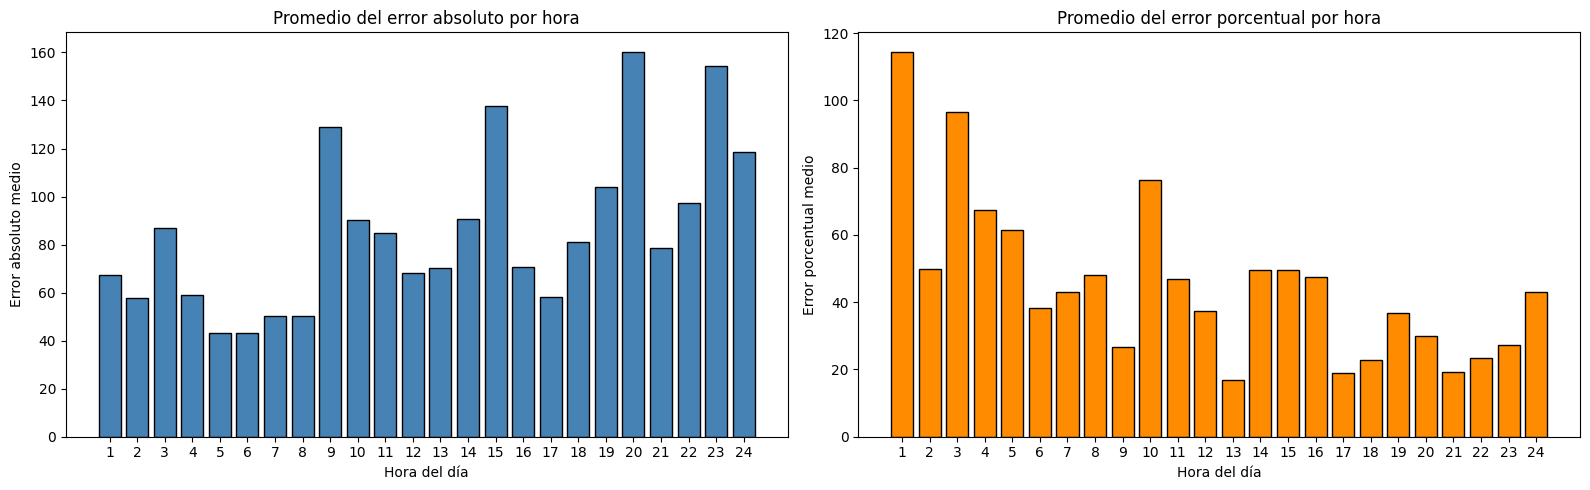

In [47]:
import matplotlib.pyplot as plt

df_error_hora = (
    df.with_columns(
        pl.col("fecha_medicion_real").dt.hour().alias("hora")
    )
    .group_by(["id_serie", "hora"])
    .agg(
        pl.mean("error_absoluto").alias("error_absoluto_medio"),
        pl.mean("error_porcentual").alias("error_porcentual_medio"),
    )
    .sort(["id_serie", "hora"])
)

df_error_hora_por_hora = (
    df_error_hora.group_by("hora")
    .agg(
        pl.mean("error_absoluto_medio").alias("error_absoluto_medio"),
        pl.mean("error_porcentual_medio").alias("error_porcentual_medio"),
    )
    .sort("hora")
    .with_columns((pl.col("hora") + 1).alias("hora_1_24"))
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True)

horas = df_error_hora_por_hora.select("hora_1_24").to_series().to_list()
error_abs = df_error_hora_por_hora.select("error_absoluto_medio").to_series().to_list()
error_pct = df_error_hora_por_hora.select("error_porcentual_medio").to_series().to_list()

axes[0].bar(horas, error_abs, color="steelblue", edgecolor="black")
axes[0].set_title("Promedio del error absoluto por hora")
axes[0].set_xlabel("Hora del día")
axes[0].set_ylabel("Error absoluto medio")
axes[0].set_xticks(list(range(1, 25)))
axes[0].set_xticklabels([str(hora) for hora in range(1, 25)])

axes[1].bar(horas, error_pct, color="darkorange", edgecolor="black")
axes[1].set_title("Promedio del error porcentual por hora")
axes[1].set_xlabel("Hora del día")
axes[1].set_ylabel("Error porcentual medio")
axes[1].set_xticks(list(range(1, 25)))
axes[1].set_xticklabels([str(hora) for hora in range(1, 25)])

plt.tight_layout()
plt.show()

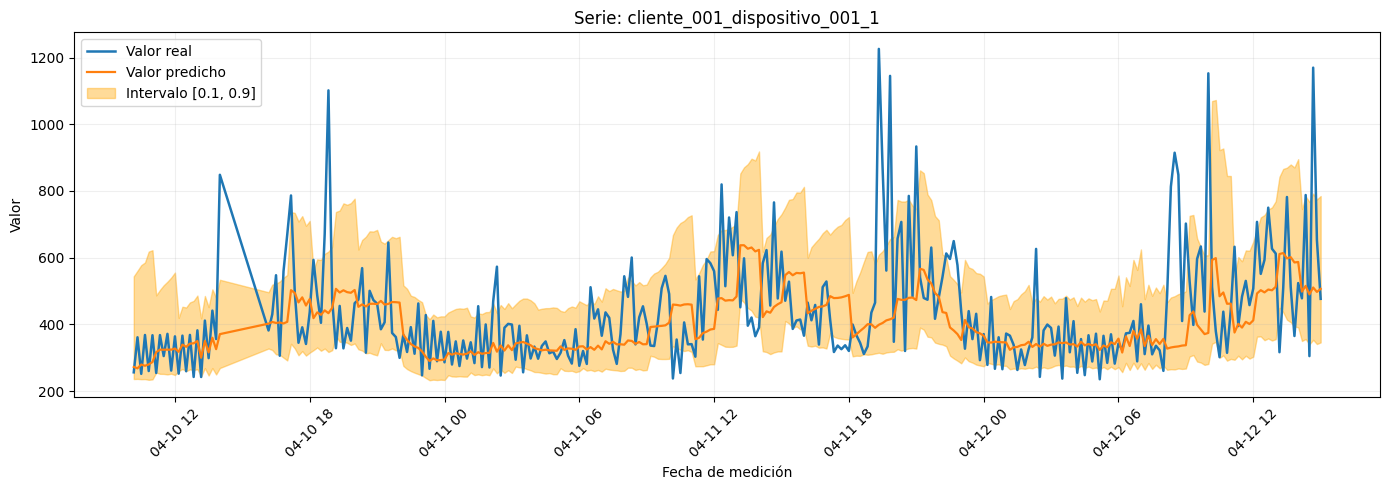

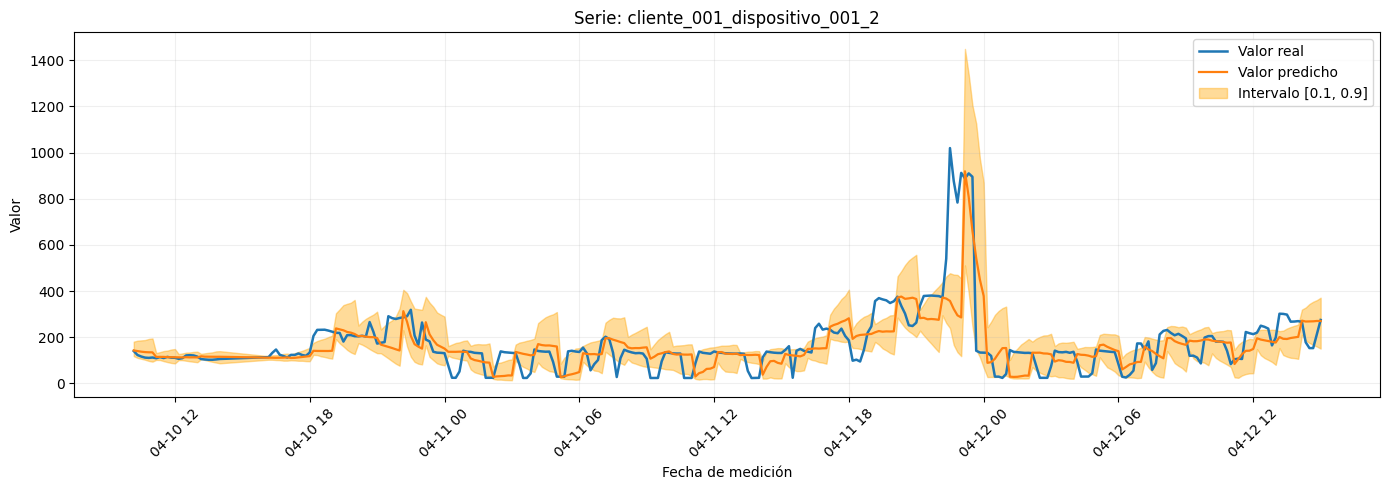

In [48]:
# Grafico por serie: valor real, valor predicho e intervalo [0.1, 0.9]
series_ids = df.select("id_serie").unique().sort("id_serie").to_series().to_list()

for serie_id in series_ids:
    df_serie = (
        df.filter(pl.col("id_serie") == serie_id)
        .sort("fecha_medicion_real")
        .select(
            "fecha_medicion_real",
            "valor_real",
            "valor_predicho",
            "intervalo_0_1",
            "intervalo_0_9",
        )
    )

    if df_serie.height == 0:
        continue

    x = df_serie.select("fecha_medicion_real").to_series().to_list()
    y_real = df_serie.select("valor_real").to_series().to_list()
    y_pred = df_serie.select("valor_predicho").to_series().to_list()
    y_low = df_serie.select("intervalo_0_1").to_series().to_list()
    y_high = df_serie.select("intervalo_0_9").to_series().to_list()

    fig, ax = plt.subplots(figsize=(14, 5))

    ax.plot(x, y_real, label="Valor real",linewidth=1.8)
    ax.plot(x, y_pred, label="Valor predicho", linewidth=1.6)
    ax.fill_between(
        x,
        y_low,
        y_high,
        color="orange",
        alpha=0.4,
        label="Intervalo [0.1, 0.9]",
    )

    ax.set_title(f"Serie: {serie_id}")
    ax.set_xlabel("Fecha de medición")
    ax.set_ylabel("Valor")
    ax.legend()
    ax.grid(alpha=0.2)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Cálculo de margen de error

In [49]:
# Contar valores fuera del intervalo y calcular porcentaje
valores_fuera_intervalo = (
    df.group_by("id_serie").agg(
        pl.when((pl.col("valor_real") < pl.col("intervalo_0_1")) | (pl.col("valor_real") > pl.col("intervalo_0_9")))
        .then(1)
        .otherwise(0)
        .sum()
        .alias("fuera_intervalo"),
        pl.col("valor_real").count().alias("total_registros")
    )
    .with_columns(
        (pl.col("fuera_intervalo") / pl.col("total_registros") * 100).round(2).alias("porcentaje")
    )
    .sort("fuera_intervalo", descending=True)
)

display(valores_fuera_intervalo)

id_serie,fuera_intervalo,total_registros,porcentaje
str,i32,u32,f64
"""cliente_001_dispositivo_001_2""",98,306,32.03
"""cliente_001_dispositivo_001_1""",81,306,26.47
